<a href="https://colab.research.google.com/github/Salahaldian/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [4]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [4]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

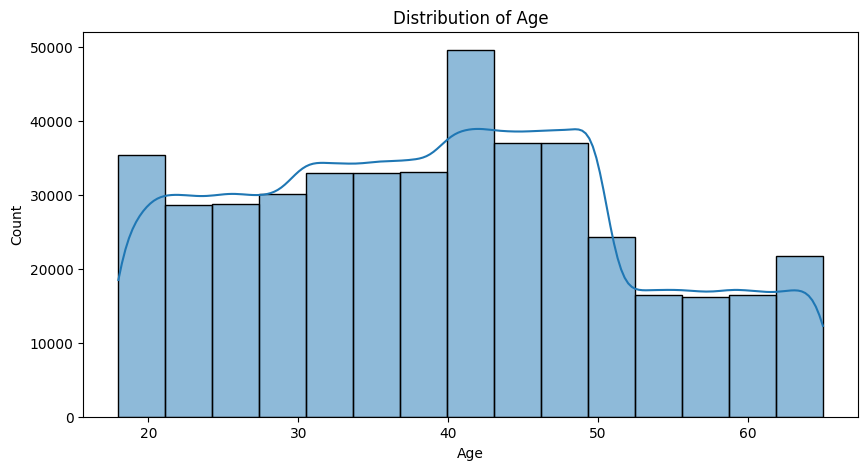

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

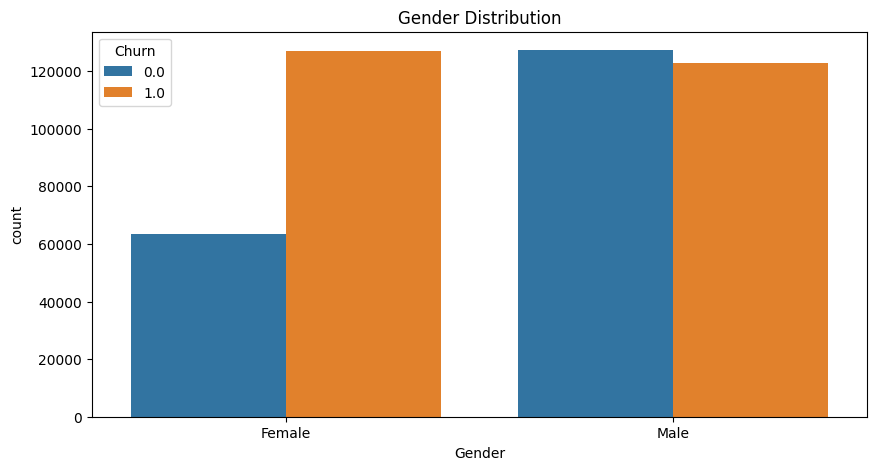

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Gender', data=df ,hue='Churn')
plt.title('Gender Distribution')
plt.show()

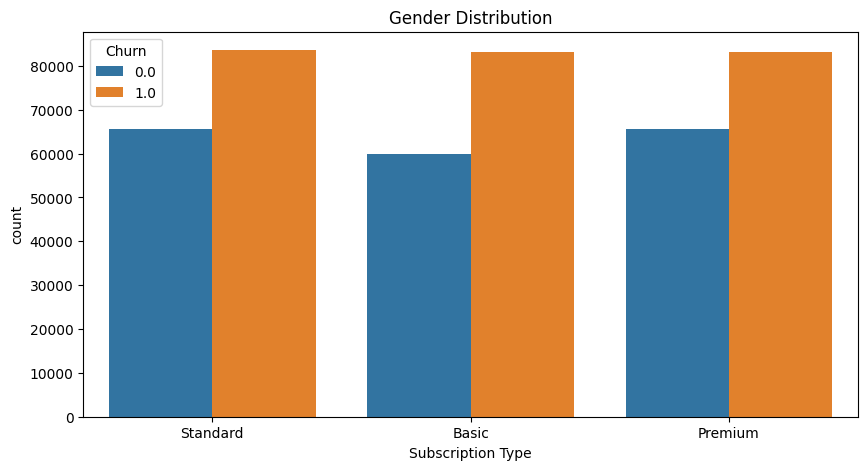

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Subscription Type', data=df ,hue='Churn')
plt.title('Gender Distribution')
plt.show()

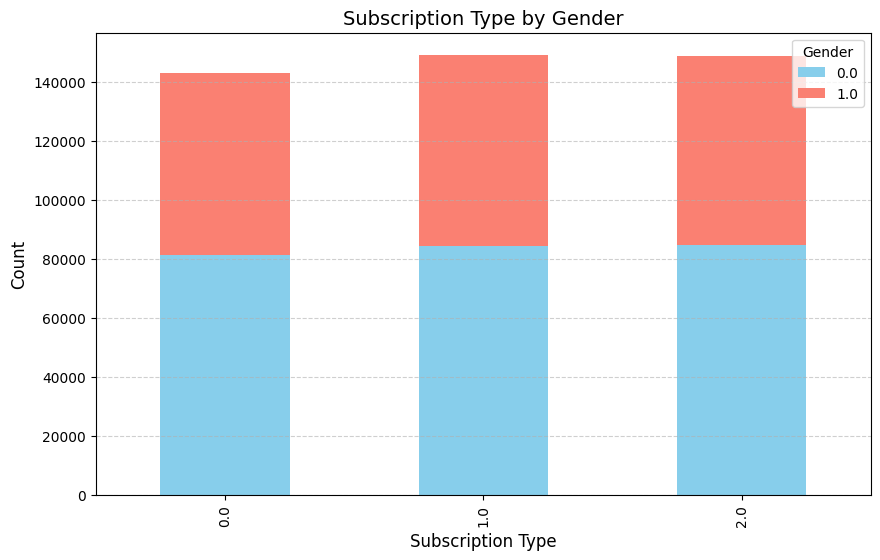

In [38]:
subscription_gender = df.groupby(['Subscription Type', 'Gender']).size().unstack()
subscription_gender.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Subscription Type by Gender', fontsize=14)
plt.xlabel('Subscription Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

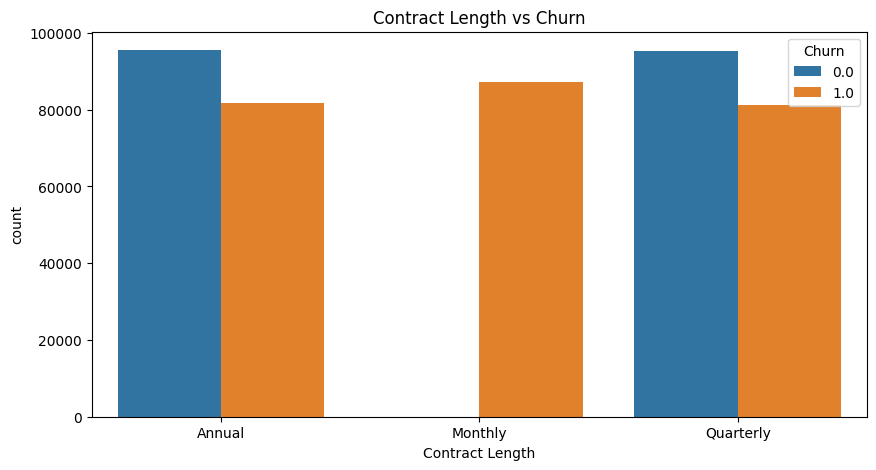

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length vs Churn')
plt.show()

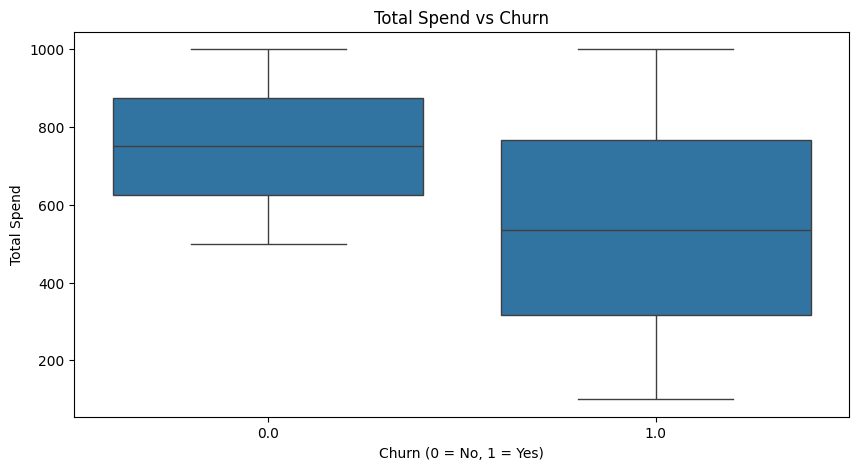

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title('Total Spend vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()

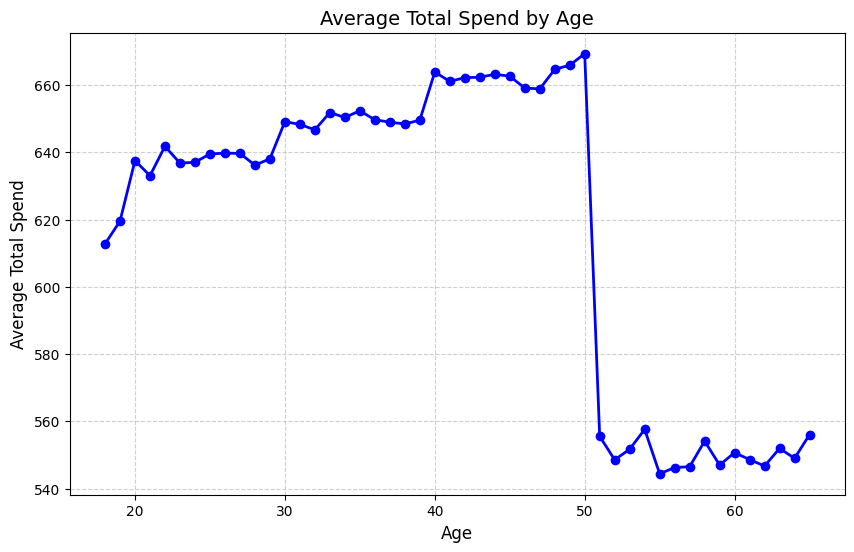

In [37]:
# حساب متوسط الإنفاق لكل عمر
age_spend = df.groupby('Age')['Total Spend'].mean()

# رسم المخطط الخطي
plt.figure(figsize=(10, 6))
plt.plot(age_spend.index, age_spend.values, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Average Total Spend by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Total Spend', fontsize=12)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

<Figure size 1000x500 with 0 Axes>

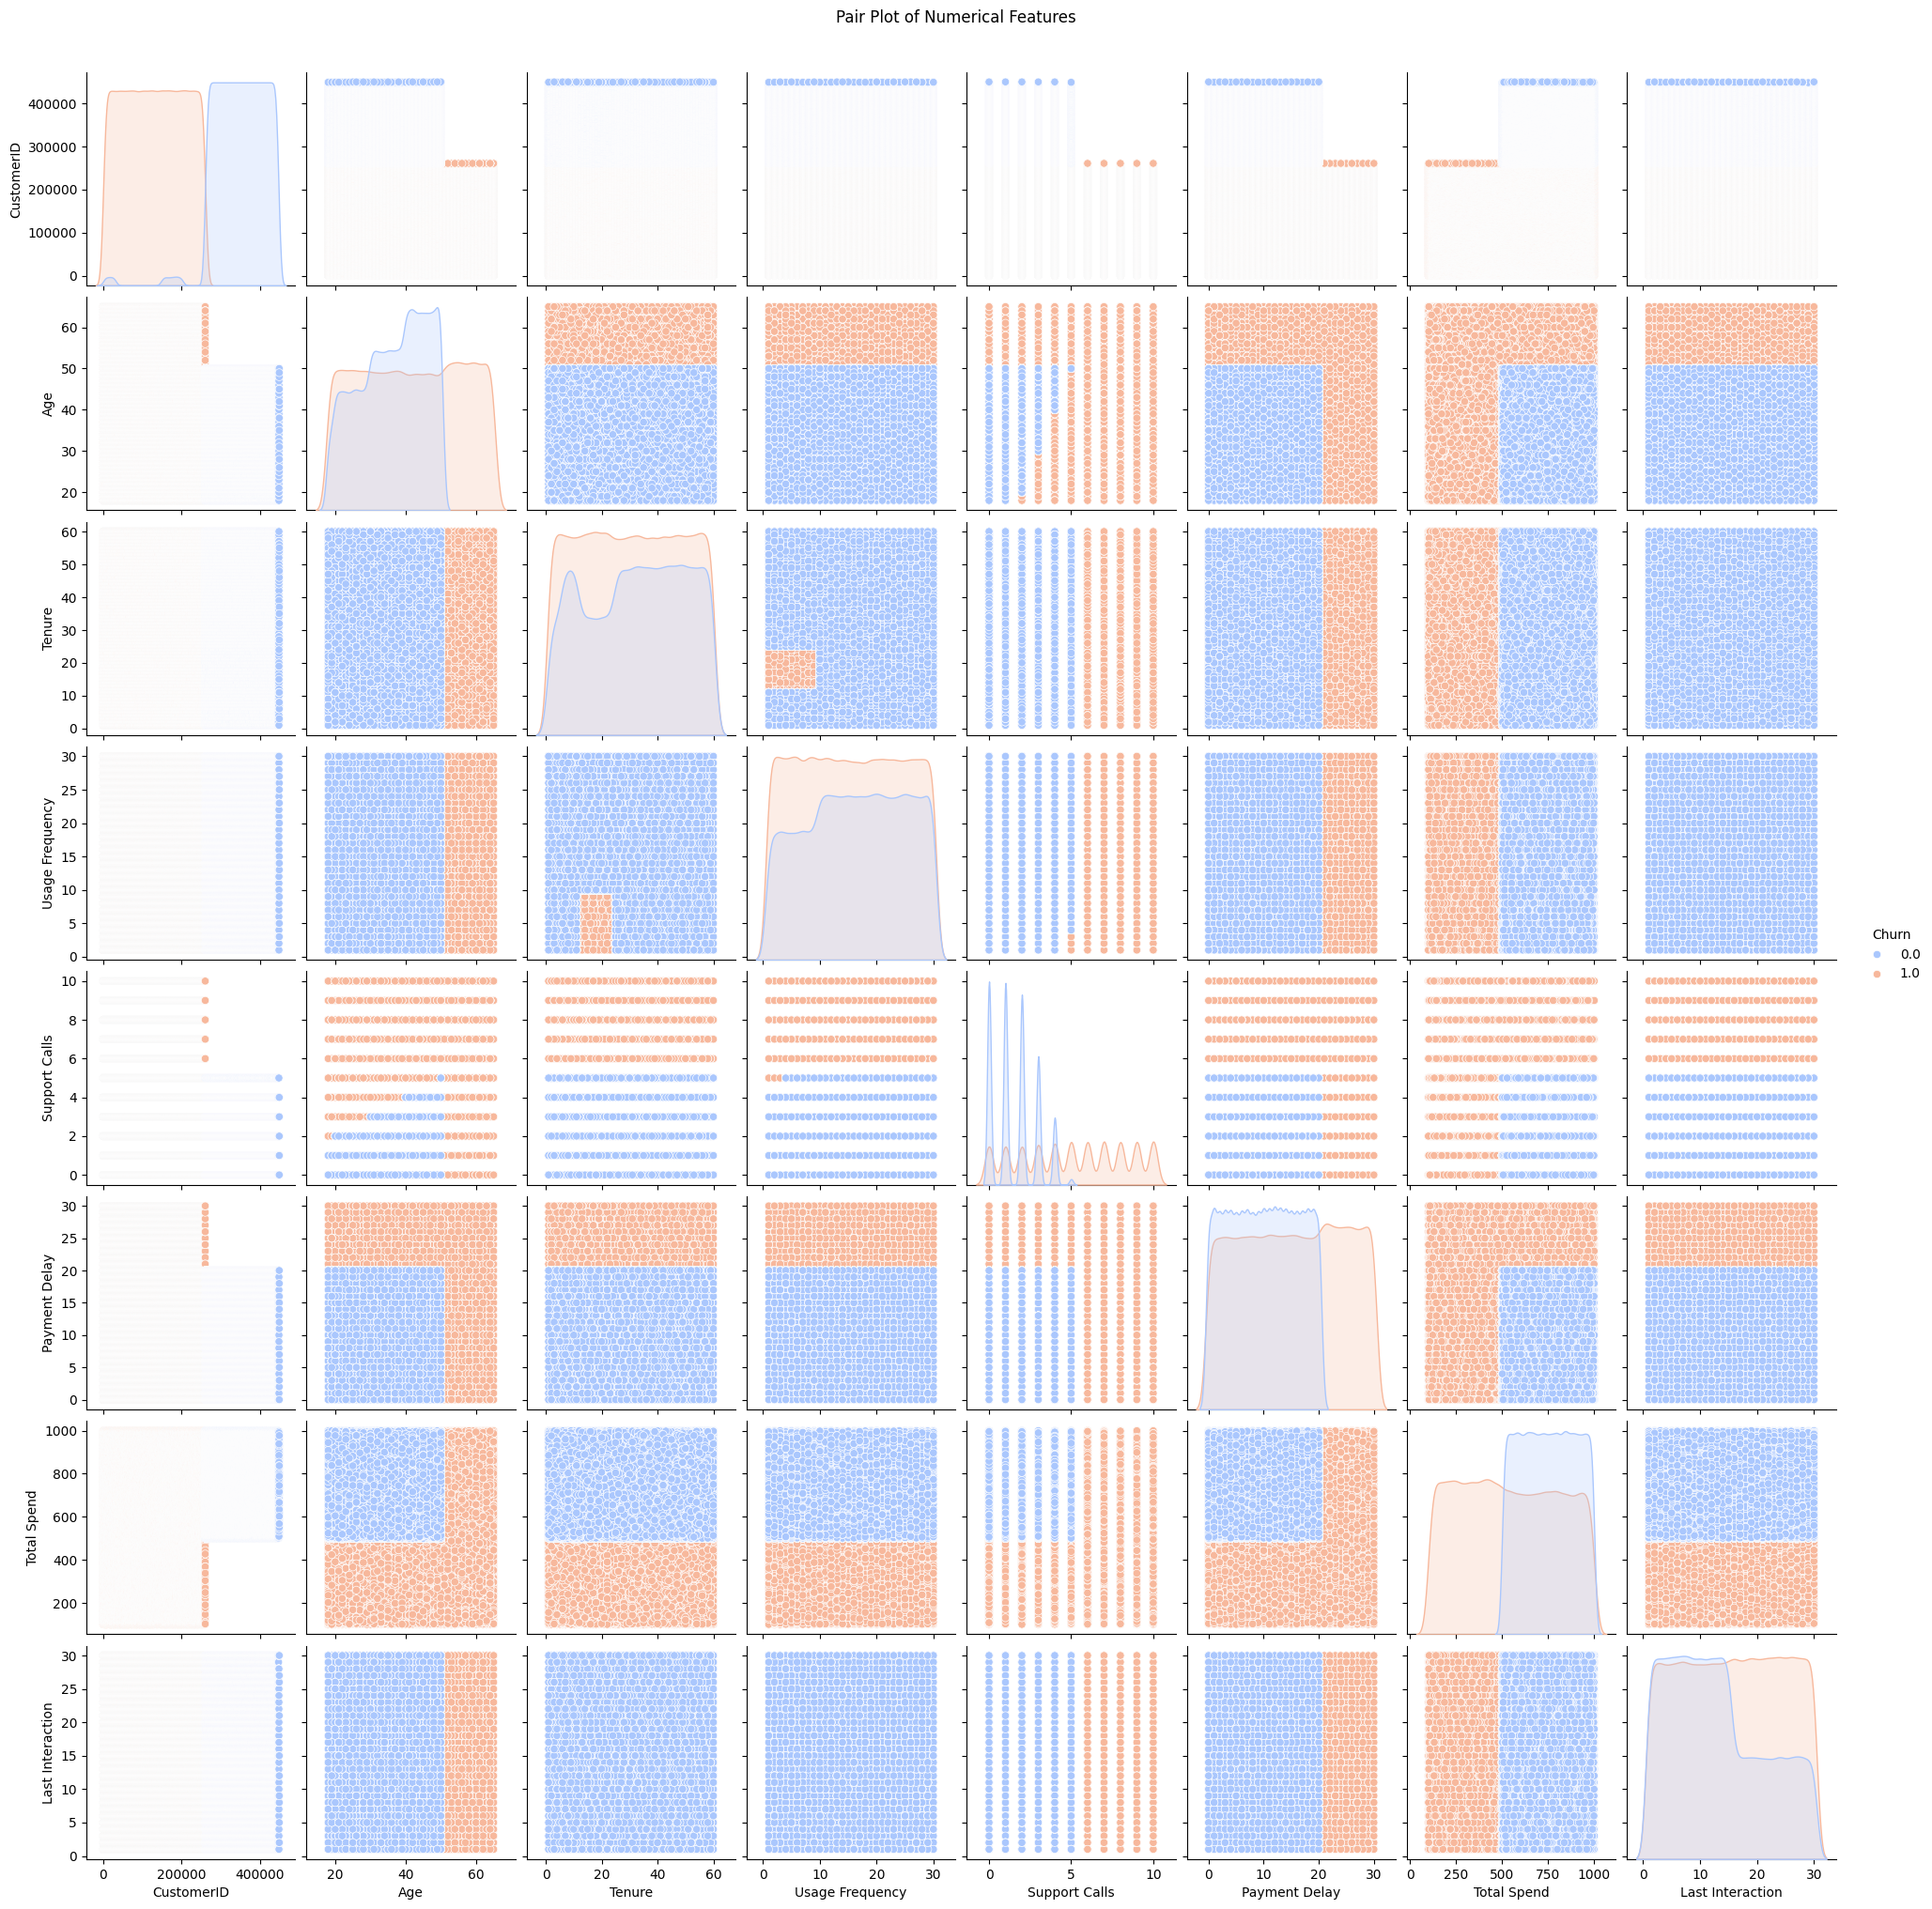

In [11]:
plt.figure(figsize=(10, 5))
sns.pairplot(df, hue='Churn', palette='coolwarm')
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [13]:
df["Gender"].value_counts()

,count
Gender,
Male,250252
Female,190580


In [14]:
df["Subscription Type"].value_counts()

,count
Subscription Type,
Standard,149128
Premium,148678
Basic,143026


In [15]:
df["Contract Length"].value_counts()

,count
Contract Length,
Annual,177198
Quarterly,176530
Monthly,87104


In [16]:
gender = {'Male': 0, 'Female': 1}
subscription = {'Basic': 0, 'Standard': 1, 'Premium': 2}
contract = {'Monthly' : 0, 'Quarterly': 1, 'Annual': 2}

df['Gender'] = df['Gender'].map(gender)
df['Subscription Type'] = df['Subscription Type'].map(subscription)
df['Contract Length'] = df['Contract Length'].map(contract)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  float64
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  float64
 8   Contract Length    440832 non-null  float64
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(12)
memory usage: 40.4 MB


In [18]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,1.0,39.0,14.0,5.0,18.0,1.0,2.0,932.00,17.0,1.0
1,3.0,65.0,1.0,49.0,1.0,10.0,8.0,0.0,0.0,557.00,6.0,1.0
2,4.0,55.0,1.0,14.0,4.0,6.0,18.0,0.0,1.0,185.00,3.0,1.0
3,5.0,58.0,0.0,38.0,21.0,7.0,7.0,1.0,0.0,396.00,29.0,1.0
4,6.0,23.0,0.0,32.0,20.0,5.0,8.0,0.0,0.0,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,0.0,54.0,15.0,1.0,3.0,2.0,2.0,716.38,8.0,0.0
440829,449996.0,25.0,1.0,8.0,13.0,1.0,20.0,2.0,2.0,745.38,2.0,0.0
440830,449997.0,26.0,0.0,35.0,27.0,1.0,5.0,1.0,1.0,977.31,9.0,0.0
440831,449998.0,28.0,0.0,55.0,14.0,2.0,0.0,1.0,1.0,602.55,2.0,0.0


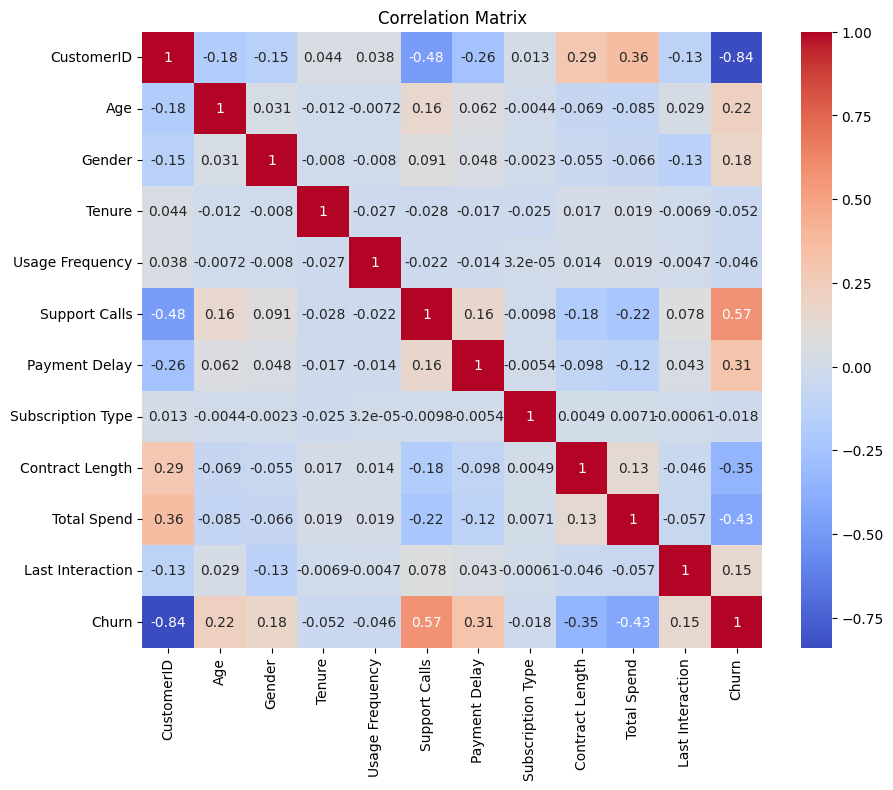

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [20]:
threshold = 0.03

correlation = df.corr()
high_corr_features = correlation.index[abs(correlation["Churn"]) > threshold].tolist()
high_corr_features.remove("Churn")
print(high_corr_features)

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction']


In [21]:
X_selected = df[high_corr_features]
Y = df["Churn"]

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X_selected, Y, test_size= 0.2 , shuffle=True, random_state=55)

In [23]:
X_train.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Contract Length,1
Total Spend,1
Last Interaction,1


In [24]:
X_train = X_train.dropna(axis=0)
X_test = X_test.dropna(axis=0)
Y_train = Y_train.dropna(axis=0)
Y_test = Y_test.dropna(axis=0)

In [25]:
X_train.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [26]:
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)

LinearRegression()

In [27]:
model_LR.score(X_train, Y_train)

0.7797281721796611

In [28]:
model_LR.score(X_test, Y_test)

0.780635232111961

In [29]:
y_pred = model_LR.predict(X_test)

In [30]:
# حساب خطأ MSE
print(mean_squared_error(Y_test, y_pred))

# حساب R^2
print(r2_score(Y_test, y_pred))

0.053858359328303435
0.780635232111961


In [31]:
model_KNN = KNeighborsClassifier(n_neighbors=3)
model_KNN.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

In [32]:
y_pred_knn = model_KNN.predict(X_test)

In [33]:
print(accuracy_score(Y_test, y_pred_knn))

0.9898828359817166


In [34]:
# حساب خطأ MSE
print(mean_squared_error(Y_test, y_pred_knn))

# حساب R^2
print(r2_score(Y_test, y_pred_knn))

0.010117164018283486
0.9587928528786492


In [35]:
model_KNN.score(X_train, Y_train)

0.9924290757517757

In [36]:
model_KNN.score(X_test, Y_test)

0.9898828359817166